# HW Retinopathy classificationV3

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from glob import glob
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
import pandas as pd

In [2]:
# Define Parameters
NUM_CLASS = 5
IMG_SIZE = 224
BS = 64
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

#### Data Visualization

In [3]:
df = pd.read_csv("/Users/adamw/tutorials/llm_tutorial/data/kaggle_retina/train.csv")
df.head()

,id_code,diagnosis
0,c1e6fa1ad314,1
1,ed246ae1ed08,4
2,4d3de40ced3a,0
3,ae8472f8d310,1
4,3c28fd846b43,0


In [4]:
paths = glob('/Users/adamw/tutorials/llm_tutorial/data/kaggle_retina/train/*.png')
paths_test = sorted(glob('/Users/adamw/tutorials/llm_tutorial/data/kaggle_retina/test/*.png'))
len(paths), len(paths_test)

(2197, 1465)

/Users/adamw/tutorials/llm_tutorial/data/kaggle_retina/train/4bd5d0b30198.png
label: 0


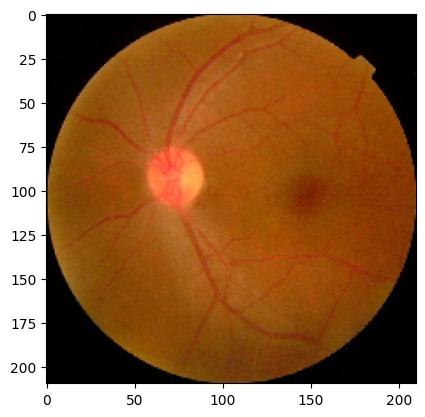

In [5]:
idx = np.random.randint(0, len(df))
row = df.iloc[idx]
filename = row["id_code"]
path = f"/Users/adamw/tutorials/llm_tutorial/data/kaggle_retina/train/{filename}.png"
img = cv2.imread(path)[:, :, ::-1]
plt.imshow(img)
print(path)
print(f'label: {row["diagnosis"]}')

In [6]:
all_cls = df['diagnosis'].tolist()
print(all_cls[:3])

[1, 4, 0]


<BarContainer object of 5 artists>

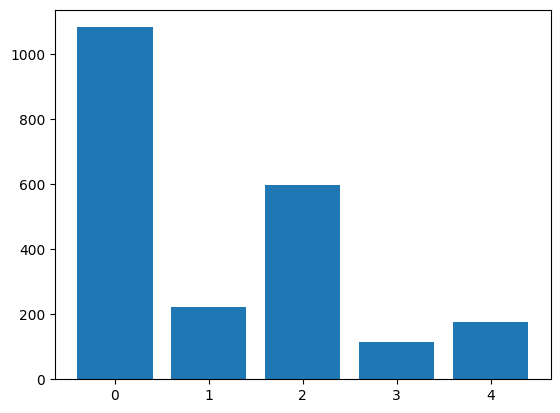

In [7]:
# Class distribution
cls, count = np.unique(all_cls, return_counts=True)
plt.bar(cls, count)

#### Dataset, DataLoader

In [8]:
class RetinaDataset(torch.utils.data.Dataset):
    def __init__(self, df, img_size=224, transform=None):
        self.df = df
        self.img_size = img_size
        
        if transform:
            self.transform = transform
        else:
            self.transform = T.Compose([
                T.Resize((self.img_size, self.img_size)),
                T.ToTensor(),
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row["id_code"]
        path = f"/Users/adamw/tutorials/llm_tutorial/data/kaggle_retina/train/{filename}.png"
        img = Image.open(path).convert('RGB')

        img = self.transform(img)

        label = row["diagnosis"]
        label = torch.tensor(label, dtype=torch.long)

        return img, label

In [9]:
df = pd.read_csv("/Users/adamw/tutorials/llm_tutorial/data/kaggle_retina/train.csv")
train_df, val_df = train_test_split(df,
                                    test_size=0.2, # 8:2
                                    random_state=5566)

In [10]:
from torchvision.models import ResNet50_Weights

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.Resize(232),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(0.5),
    T.RandomVerticalFlip(0.5),
    T.RandomRotation(30),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])
eval_tf = ResNet50_Weights.DEFAULT.transforms()

train_ds = RetinaDataset(train_df, img_size=IMG_SIZE, transform=train_tf)
val_ds = RetinaDataset(val_df, img_size=IMG_SIZE, transform=eval_tf)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..1.7522904].


1667 tensor(4)


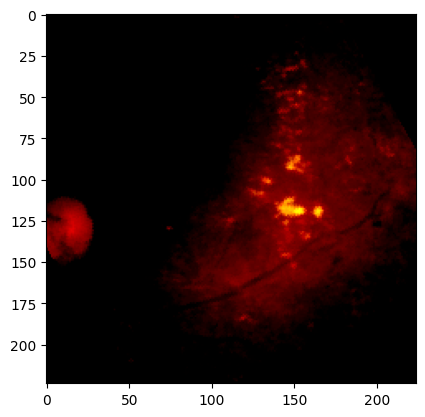

In [11]:
idx = np.random.randint(0, len(train_ds))
img, label = train_ds[idx]
print(idx, label)
plt.imshow(img.permute(1, 2, 0))
plt.show()

In [12]:
train_loader = torch.utils.data.DataLoader(train_ds, BS, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, BS)

#### Model

In [13]:
import torchvision
model = torchvision.models.resnet50(weights='DEFAULT').to(device)

In [14]:
from torchinfo import summary
summary(model, input_size=(2, 3, 224, 224), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [2, 1000]                 --
├─Conv2d: 1-1                            [2, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [2, 64, 112, 112]         128
├─ReLU: 1-3                              [2, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [2, 64, 56, 56]           --
├─Sequential: 1-5                        [2, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [2, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [2, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [2, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [2, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [2, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [2, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [2, 64, 56, 56]           --
│ 

In [15]:
# Freeze the model parameters 
FREEZE = False

if FREEZE:
    for params in model.fc.parameters():
        params.requires_grad = False

# Replace the final layer to match the number of classes
model.fc = nn.Linear(2048, NUM_CLASS).to(device)

for params in model.fc.parameters():
    params.requires_grad = True

model = model.to(device)

In [16]:
summary(model, (2, 3, 224, 224), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [2, 5]                    --
├─Conv2d: 1-1                            [2, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [2, 64, 112, 112]         128
├─ReLU: 1-3                              [2, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [2, 64, 56, 56]           --
├─Sequential: 1-5                        [2, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [2, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [2, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [2, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [2, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [2, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [2, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [2, 64, 56, 56]           --
│ 

In [17]:
# 測試模型輸出
outputs = model(torch.randn(2, 3, 224, 224).to(device))
outputs.shape

torch.Size([2, 5])

#### Training

In [18]:
counts = train_df['diagnosis'].value_counts().sort_index()
counts

diagnosis
0    853
1    181
2    489
3     91
4    143
Name: count, dtype: int64

In [19]:
# w = torch.tensor(counts.sum() / (len(counts) * counts), dtype=torch.float).to(device)
# w

In [20]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [21]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset) # number of samples
    num_batches = len(dataloader) # batches per epoch

    model.train() # to training mode.
    epoch_loss, epoch_correct = 0, 0
    for batch_i, (x, y) in enumerate(tqdm(dataloader, leave=False)):
        x, y = x.to(device), y.to(device) # move data to GPU

        # zero the parameter gradients
        optimizer.zero_grad()

        # Compute prediction loss
        pred = model(x)
        loss = loss_fn(pred, y)

        # Optimization by gradients
        loss.backward() # backpropagation to compute gradients
        optimizer.step() # update model params

        # write to logs
        epoch_loss += loss.item() # tensor -> python value
        # (N, Class)
        epoch_correct += (pred.argmax(dim=1) == y).sum().item()

    # return avg loss of epoch, acc of epoch
    return epoch_loss/num_batches, epoch_correct/size


def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset) # number of samples
    num_batches = len(dataloader) # batches per epoch

    model.eval() # model to test mode.
    epoch_loss, epoch_correct = 0, 0

    # No gradient for test data
    with torch.no_grad():
        for batch_i, (x, y) in enumerate(dataloader):
            x, y = x.to(device), y.to(device)

            # Compute prediction loss
            pred = model(x)
            loss = loss_fn(pred, y)

            # write to logs
            epoch_loss += loss.item()
            epoch_correct += (pred.argmax(1) == y).sum().item()

    return epoch_loss/num_batches, epoch_correct/size

In [22]:
EPOCHS = 50
FREEZE = True
logs = {
    'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []
}
# Earlystopping
patience = 10 
counter = 0
best_loss = np.inf

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

for epoch in tqdm(range(EPOCHS)):
    train_loss, train_acc = train(train_loader, model, loss_fn, optimizer)
    val_loss, val_acc = test(val_loader, model, loss_fn)

    print(f'EPOCH: {epoch:04d} \
    train_loss: {train_loss:.4f}, train_acc: {train_acc:.3f} \
    val_loss: {val_loss:.4f}, val_acc: {val_acc:.3f} ')

    logs['train_loss'].append(train_loss)
    logs['train_acc'].append(train_acc)
    logs['val_loss'].append(val_loss)
    logs['val_acc'].append(val_acc)

    torch.save(model.state_dict(), os.path.join(MODEL_DIR, "last.pth"))
    # chcek improvement
    if val_loss < best_loss:
        counter = 0
        best_loss = val_loss
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, "best.pth"))
    else:
        counter += 1
        print(f"Earlystop counter: {counter} out of {patience}")
    if counter >= patience:
        print("Earlystop!")
        break

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

EPOCH: 0000     train_loss: 1.0793, train_acc: 0.637     val_loss: 0.7397, val_acc: 0.745 


  0%|          | 0/28 [00:00<?, ?it/s]

EPOCH: 0001     train_loss: 0.7153, train_acc: 0.733     val_loss: 0.6314, val_acc: 0.766 


...

EPOCH: 0012     train_loss: 0.2620, train_acc: 0.910     val_loss: 0.5631, val_acc: 0.811 
Earlystop counter: 8 out of 10


  0%|          | 0/28 [00:00<?, ?it/s]

EPOCH: 0013     train_loss: 0.2407, train_acc: 0.915     val_loss: 0.6364, val_acc: 0.809 
Earlystop counter: 9 out of 10


  0%|          | 0/28 [00:00<?, ?it/s]

EPOCH: 0014     train_loss: 0.2371, train_acc: 0.916     val_loss: 0.7166, val_acc: 0.814 
Earlystop counter: 10 out of 10
Earlystop!


## Eval

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import numpy as np

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in val_loader:
        p = model(x.to(device)).argmax(1).cpu()
        y_pred.append(p); y_true.append(y)
y_true = torch.cat(y_true).numpy(); y_pred = torch.cat(y_pred).numpy()

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=3))   # 看每類 recall
print('QWK:', cohen_kappa_score(y_true, y_pred, weights='quadratic'))  # DR 標準指標

[[229   0   1   0   0]
 [  9   6  24   0   2]
 [  1   1 101   4   3]
 [  0   0  10  10   5]
 [  0   0  16   6  12]]
              precision    recall  f1-score   support

           0      0.958     0.996     0.977       230
           1      0.857     0.146     0.250        41
           2      0.664     0.918     0.771       110
           3      0.500     0.400     0.444        25
           4      0.545     0.353     0.429        34

    accuracy                          0.814       440
   macro avg      0.705     0.563     0.574       440
weighted avg      0.817     0.814     0.785       440

QWK: 0.8859964208927169


#### Kaggle Submission

https://www.kaggle.com/competitions/diabetic-retinopathy-classification-3/overview

In [24]:
model.load_state_dict(torch.load(os.path.join("models", "best.pth")))
_ = model.eval().to(device)

In [25]:
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform        # 從外面傳進來，與 val 共用同一前處理

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row["id_code"]
        path = f"/Users/adamw/tutorials/llm_tutorial/data/kaggle_retina/test/{filename}.png"
        img = Image.open(path).convert('RGB')
        img = self.transform(img)

        return img

df = pd.read_csv('/Users/adamw/tutorials/llm_tutorial/data/kaggle_retina/submission.csv')
test_ds = TestDataset(df, transform=eval_tf)   # 與 val 完全相同的 eval 前處理（含 Normalize）
test_loader = torch.utils.data.DataLoader(test_ds, BS)


In [26]:
# Inference
y_pred = []
with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        pred = model(x)
        y_pred.append(pred.argmax(dim=1))

y_pred = torch.cat(y_pred, dim=0).cpu().numpy()

In [27]:
df['diagnosis'] = y_pred
df.to_csv('AIMD_BA28-11.csv_lesson4HW_exp3.csv', index=None)


Baseline: 0.7979

with aug: 0.7839
